# Analysis of the Relationship between Covid Policies and Mental Health

## Overview (README)

"*How heavily did a state’s COVID-19 measurement policy have an impact on mental health 
compared to its counterparts?*"

- **Target variable:** 
- **Features:** 
- **Final dataset shape:** 

- **Phase 1:** 
- **Phase 2:** 
- **Phase 3:** 
- **Phase 4:** 


---

## Data Loading and Cleaning

Load data, handle missing values, final shape. One markdown cell explaining your dataset and where it came from.

Cut: Every failed cleaning
attempt. Show the final
pipeline only.

In [8]:
# Download the required datasets
import os
import urllib.request
import pandas as pd
import numpy as np

os.makedirs("dataset", exist_ok=True)

file_path_1 = "dataset/cdc_depression_data.csv"
file_path_2 = "dataset/OxCGRT_simplified_v1.csv"
file_path_3 = "dataset/final_dataset.csv"
url_path_1 = "https://data.cdc.gov/api/views/8pt5-q6wp/rows.csv?accessType=DOWNLOAD"
url_path_2 = "https://github.com/OxCGRT/covid-policy-dataset.git"

if not os.path.exists(file_path_1):
    print("Downloading CDC depression dataset from data.gov ...")
    urllib.request.urlretrieve(
        url_path_1,
        file_path_1
    )
else:
    print("Dataset already exists. Skipping download.")

if not os.path.exists(file_path_2):
    print("Downloading OxCGRT dataset from GitHub ...")
    # Clone the repository and move the file
    os.system("git clone " + url_path_2)
    os.system("mv covid-policy-dataset/data/OxCGRT_simplified_v1.csv dataset/")
    os.system("rm -rf covid-policy-dataset")
else:
    print("Dataset already exists. Skipping download.")


depression_data = pd.read_csv(file_path_1, low_memory=False)
oxcgrt_data = pd.read_csv(file_path_2, low_memory=False)

# Filter the simplified OxCGRT dataset for the United States
oxcgrt_us = oxcgrt_data[oxcgrt_data['CountryName'] == 'United States']

# Remove some unnecessary columns that we won't be using for our analysis
columns_to_drop = ['CountryName', 'CountryCode', 'RegionCode', 'Jurisdiction']
columns_to_drop += [col for col in oxcgrt_us.columns if col.endswith('_combined') and not col.endswith('_combined_numeric')]
oxcgrt_us = oxcgrt_us.drop(columns=columns_to_drop)

# Fill missing values in the 'RegionName' column with 'United States'
# Required for merging with the depression dataset, which does expect 'United States' for country-level data
oxcgrt_us.loc[oxcgrt_us['RegionName'].isna() | (oxcgrt_us['RegionName'] == ''), 'RegionName'] = 'United States'

# Rename all rows of 'RegionName' from 'Washington DC' to 'District of Columbia'
# We discovered at inspection, that a mismatching name between the two datasets was causing issues with merging
oxcgrt_us.loc[oxcgrt_us['RegionName'] == 'Washington DC', 'RegionName'] = 'District of Columbia'

# Get unique time periods and state combinations from the depression dataset
unique_time_state_combs = depression_data[['Time Period Start Date', 'Time Period End Date', 'State']].drop_duplicates()

# Convert 'Time Period Start Date' and 'Time Period End Date' to int YYYYMMDD format
unique_time_state_combs['Time Period Start Date'] = pd.to_datetime(
    unique_time_state_combs['Time Period Start Date'], format='%m/%d/%Y'
).dt.strftime('%Y%m%d').astype('int64')
unique_time_state_combs['Time Period End Date'] = pd.to_datetime(
    unique_time_state_combs['Time Period End Date'], format='%m/%d/%Y', errors='coerce'
).dt.strftime('%Y%m%d').astype('int64')

# Sort the rows of the OxCGRT dataset into groups, based on the unique time-state combinations from the depression dataset
# Add 'Start' and 'End' columns to the OxCGRT dataset and fill them based on the unique time-state combinations
# These will be matched to the depression dataset later when we do the merge, so we can easily filter OxCGRT data for the relevant time periods and states
oxcgrt_us['Start'] = np.nan
oxcgrt_us['End'] = np.nan

for start, end, state in unique_time_state_combs.values:
    mask = (
        (oxcgrt_us['RegionName'] == state) &
        (oxcgrt_us['Date'] >= start) &
        (oxcgrt_us['Date'] <= end)
    )
    oxcgrt_us.loc[mask, 'Start'] = start
    oxcgrt_us.loc[mask, 'End'] = end

# Now we can drop the 'Date' column, as we have the 'Start' and 'End' columns to indicate the relevant time periods for each row
oxcgrt_us = oxcgrt_us.drop(columns=['Date'])

# Convert the 'PopulationVaccinated' column to numeric
# (It was imported as an object, need to convert it to numeric for aggregation)
oxcgrt_us['PopulationVaccinated'] = pd.to_numeric(oxcgrt_us['PopulationVaccinated'])

# Aggregate the OxCGRT data by group (unique time-state combinations) using median for numeric columns
oxcgrt_aggregated = (
    oxcgrt_us
    .dropna(subset=['Start', 'End'])
    .groupby(['RegionName', 'Start', 'End'], as_index=False)
    .median(numeric_only=True)
)

# Add MajorityVaccinated back SAFELY (no .values)
# We did not list this merge in our explanation in the notebook, as it is not a merge between our different datasets
# We just add the 'MajorityVaccinated' column back to the aggregated dataset, as it is a non-numeric column that we cannot aggregate using median
majority = (
    oxcgrt_us
    .dropna(subset=['Start', 'End'])
    .groupby(['RegionName', 'Start', 'End'], as_index=False)['MajorityVaccinated']
    .first()
)

oxcgrt_aggregated = oxcgrt_aggregated.merge(
    majority, on=['RegionName', 'Start', 'End'], how='left'
)

# Now we can merge the depression dataset with the aggregated OxCGRT dataset based on the unique time-state combinations
# Beforehand we need to convert the 'Time Period Start Date' and 'Time Period End Date' columns in the depression dataset (such as in the cell before)
converted_depression_data = depression_data.copy()
converted_depression_data['Time Period Start Date'] = pd.to_datetime(
    converted_depression_data['Time Period Start Date'], format='%m/%d/%Y'
).dt.strftime('%Y%m%d').astype('int64')
converted_depression_data['Time Period End Date'] = pd.to_datetime(
    converted_depression_data['Time Period End Date'], format='%m/%d/%Y', errors='coerce'
).dt.strftime('%Y%m%d').astype('int64')

rows_before_left = len(converted_depression_data)
rows_before_right = len(oxcgrt_aggregated)

# Merge the datasets based on the state and time period columns
merged = converted_depression_data.merge(
    oxcgrt_aggregated,
    left_on=['State', 'Time Period Start Date', 'Time Period End Date'],
    right_on=['RegionName', 'Start', 'End'],
    how='left'
)

rows_after = len(merged)

print("Rows before merge (depression):", rows_before_left)
print("Rows before merge (policy aggregated):", rows_before_right)
print("Rows after merge:", rows_after)

# Clean up merged dataset
merged = merged.drop(columns=['RegionName', 'Start', 'End']) # Redundant after merge
# merged = merged.drop(columns=['Time Period Start Date', 'Time Period End Date']) # Optional, as the Time Period Label already indicates the time period

# Drop all rows with missing values in 'Value' and 'StringencyIndex'
filtered_merged = merged.dropna(subset=['Value', 'StringencyIndex_Average'])

# Save the merged dataset to a new CSV file
filtered_merged.to_csv(file_path_3, index=False)
print("Final merged dataset shape (rows, cols):", filtered_merged.shape)


Cloning into 'covid-policy-dataset'...
Updating files: 100% (31/31), done.


Rows before merge (depression): 16794
Rows before merge (policy aggregated): 2713
Rows after merge: 16794
Final merged dataset shape (rows, cols): (11412, 42)


---

## EDA

Three to five visualizations
that tell a story. The scatter
plot that motivated your
feature. The correlation
value. A brief written
interpretation of each

Cut: Every exploratory plot you
made. Keep only the ones
that informed a decision

Numeric columns and their ranges:
    Time Period: 1.00 to 52.00
    Time Period Start Date: 20200423.00 to 20221209.00
    Time Period End Date: 20200505.00 to 20221219.00
    Value: 6.40 to 82.00
    Low CI: 4.50 to 73.60
    High CI: 7.90 to 88.80
    C1M_combined_numeric: 0.00 to 3.00
    C2M_combined_numeric: 0.00 to 3.00
    C3M_combined_numeric: 0.00 to 2.00
    C4M_combined_numeric: 0.00 to 4.00
    C5M_combined_numeric: 0.00 to 2.00
    C6M_combined_numeric: 0.00 to 2.00
    C7M_combined_numeric: 0.00 to 2.00
    C8EV_combined_numeric: 1.00 to 3.00
    E1_combined_numeric: 0.00 to 2.00
    E2_combined_numeric: 0.00 to 2.00
    H1_combined_numeric: 1.50 to 2.00
    H2_combined_numeric: 1.00 to 3.00
    H3_combined_numeric: 1.00 to 2.00
    H6M_combined_numeric: 0.00 to 4.00
    H7_combined_numeric: 0.00 to 5.00
    H8M_combined_numeric: 0.50 to 3.00
    V1..summary.: 0.00 to 2.00
    V2..summary.: 0.00 to 3.00
    V3..summary.: 0.00 to 5.00
    V4..summary.: 0.00 to 1.00
    Co

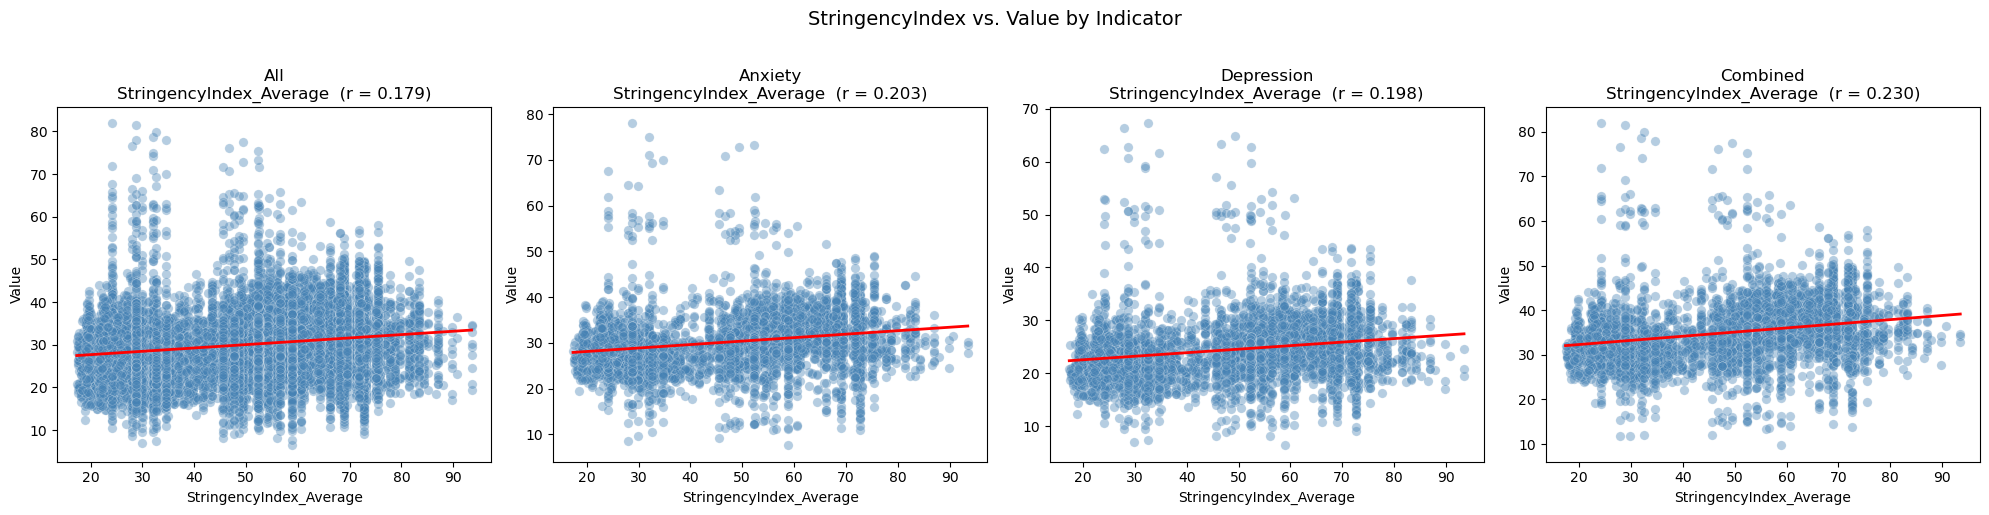

Shape of original df: (11412, 42)
Shape of anxiety df: (3804, 42)
Shape of depression df: (3804, 42)
Shape of combined df: (3804, 42)


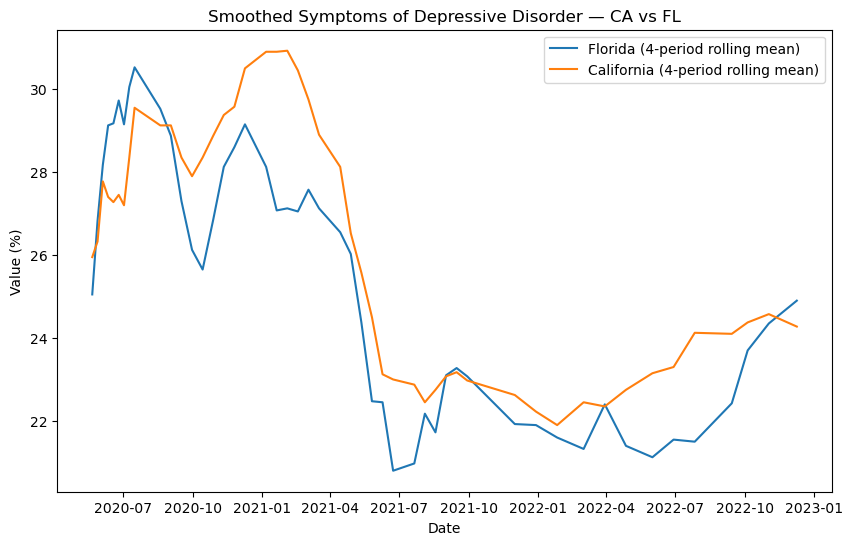

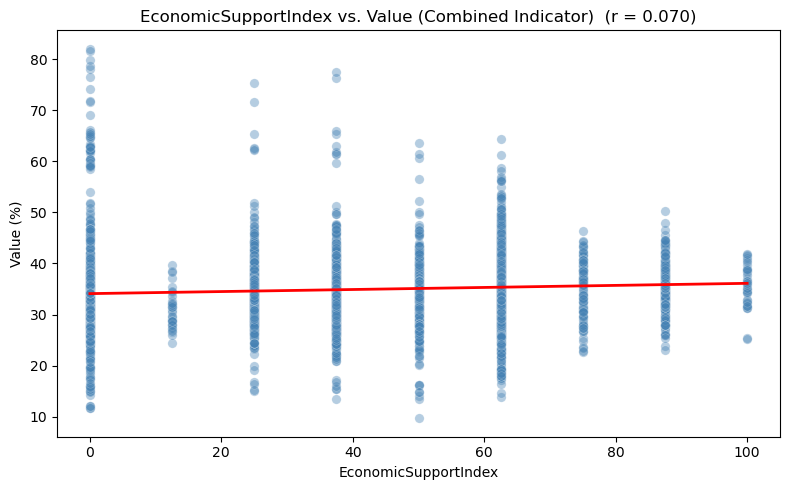

Correlation: r = 0.070


In [18]:
# Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. StreingencyIndex vs Value by Indicator - 4 Scatter with r-values
# Scatter plot

df = filtered_merged.copy()

# Second df: Filter for Symptoms of Anxiety Disorder and for State == United States
df_anxiety = df[df['Indicator'] == 'Symptoms of Anxiety Disorder']
# Third df: Filter for Symptoms of Depressive Disorder
df_depression = df[df['Indicator'] == 'Symptoms of Depressive Disorder']
# Fourth df: Filter for Symptoms of Anxiety or Depressive Disorder
df_combined = df[df['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder']

# Print out lowest and highest values for each numeric column
print("Numeric columns and their ranges:")
for col in df.select_dtypes(include=[np.number]).columns:
    print(f"    {col}: {df[col].min():.2f} to {df[col].max():.2f}")

def plot_scatter(dataframes: list, numeric_cols: list, labels: list = None):
    cols = len(dataframes)
    rows = len(numeric_cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    
    # Normalize to 2D array
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes[np.newaxis, :]
    elif cols == 1:
        axes = axes[:, np.newaxis]

    for col_idx, df in enumerate(dataframes):
        for row_idx, col in enumerate(numeric_cols):
            ax = axes[row_idx, col_idx]
            ax.scatter(df[col], df['Value'], alpha=0.4, color='steelblue',
                       edgecolors='white', linewidths=0.3, s=45)
            r = df[col].corr(df['Value'])
            x, y = df[col], df['Value']
            mask = x.notna() & y.notna()
            z = np.polyfit(x[mask], y[mask], 1)
            p = np.poly1d(z)
            ax.plot(sorted(x[mask]), p(sorted(x[mask])), color='red', linewidth=2)
            ax.set_xlabel(col)
            ax.set_ylabel("Value")
            title = labels[col_idx] if labels else f"df[{col_idx}]"
            ax.set_title(f"{title}\n{col}  (r = {r:.3f})")

    plt.suptitle("StringencyIndex vs. Value by Indicator", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("08_feature_correlations.png", dpi=120, bbox_inches='tight')
    plt.show()

labels = ['All', 'Anxiety', 'Depression', 'Combined']
numeric_cols = ['StringencyIndex_Average']
dataframes = [df, df_anxiety, df_depression, df_combined]
plot_scatter(dataframes, numeric_cols, labels=labels)

# Print the shape of each dataframe
print(f"Shape of original df: {df.shape}")
print(f"Shape of anxiety df: {df_anxiety.shape}")
print(f"Shape of depression df: {df_depression.shape}")
print(f"Shape of combined df: {df_combined.shape}")


# 2. Smoothed CA vs FL Depression over time
data = pd.read_csv(file_path_3, low_memory=False)
# Redo the second plot from Phase 2 here.

# Original code from Phase 2
x = data[(data["Indicator"]=="Symptoms of Depressive Disorder") &
        (data["Group"]=="By State") &
        (data["State"].isin(["California","Florida"]))].copy()

x["date"] = pd.to_datetime(x["Time Period Start Date"].astype(str), format="%Y%m%d", errors="coerce")
x["Value"] = pd.to_numeric(x["Value"], errors="coerce")

wide = x.dropna(subset=["date","Value"]).pivot_table(index="date", columns="State", values="Value", aggfunc="mean").sort_index()

# Add smoothed versions
# Averages over 4 values
wide["California_smooth"] = wide["California"].rolling(window=4).mean()
wide["Florida_smooth"] = wide["Florida"].rolling(window=4).mean()

# Plot
plt.figure(figsize=(10,6)) # Figure size
plt.plot(wide.index, wide["Florida_smooth"], label="Florida (4-period rolling mean)") # Florida
plt.plot(wide.index, wide["California_smooth"], label="California (4-period rolling mean)") # Cal

plt.title("Smoothed Symptoms of Depressive Disorder — CA vs FL")
plt.xlabel("Date")
plt.ylabel("Value (%)")
plt.legend()
plt.show()

# 3. EconomicSupportIndex vs. Value (Combined indicator)
# Motivates our Phase 4 interaction term: StringencyIndex × EconomicSupportIndex

x = df_combined['EconomicSupportIndex']
y = df_combined['Value']
mask = x.notna() & y.notna()
r = x[mask].corr(y[mask])

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.4, color='steelblue',
            edgecolors='white', linewidths=0.3, s=45)
z = np.polyfit(x[mask], y[mask], 1)
p = np.poly1d(z)
plt.plot(sorted(x[mask]), p(sorted(x[mask])), color='red', linewidth=2)

plt.title(f"EconomicSupportIndex vs. Value (Combined Indicator)  (r = {r:.3f})")
plt.xlabel("EconomicSupportIndex")
plt.ylabel("Value (%)")
plt.tight_layout()
plt.show()

print(f"Correlation: r = {r:.3f}")


---

## Baseline Model

Constant model MSE and
RMSE. The written
interpretation of what that
number means in your
target variable units.

Cut: No cuts. This section is
already lean.

In [21]:
# Get the mean for the target = Value
Y = df_combined['Value'].values.astype(float) # The target variable
X = df_combined['StringencyIndex_Average'].values.astype(float) # The feature variable

y_mean = Y.mean() # type: ignore
constant_prediction = np.full_like(Y, y_mean) # A constant prediction array with the same shape as Y

def mse(y_true, y_pred):
    errors = y_true - y_pred
    return np.mean(errors ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

baseline_mse  = mse(Y, constant_prediction)
baseline_rmse = rmse(Y, constant_prediction)

print("=== Constant Model Baseline ===")
print(f"Predicting {y_mean:,.2f} for the depression/anxiety score")
print(f"MSE:  {baseline_mse:>20,.2f}")
print(f"RMSE:  {baseline_rmse:>18,.2f}\n")
print("Any model we build must beat this RMSE to be useful.")

=== Constant Model Baseline ===
Predicting 34.98 for the depression/anxiety score
MSE:                 56.40
RMSE:                7.51

Any model we build must beat this RMSE to be useful.


---

## Simple Linear Regression

Model equation written out.
Sklearn verification. Scatter
plot with regression line.
Phase 3 residual plot.
Written interpretation of
both.

Cut: Manual implementation
helper functions can be
collapsed or removed.
Keep the results, not the
scaffolding.

Manual intercept:  30.4653
Manual slope:      0.0929
Predicted Value 37.21687131344451 = 30.47 + 0.0929 * 72.69
Sklearn intercept: 30.4653
Sklearn slope:     0.0929
Manual intercept == Sklearn intercept? Yes
Manual slope == Sklearn slope? Yes


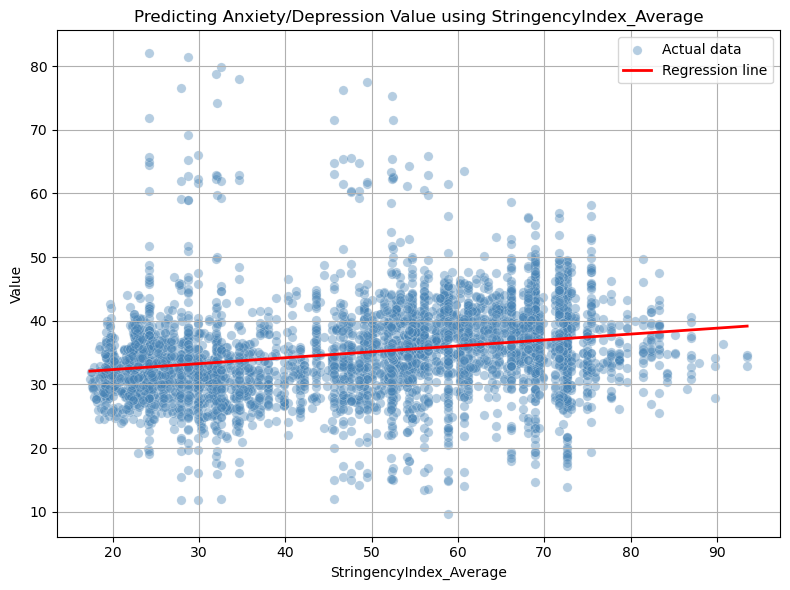

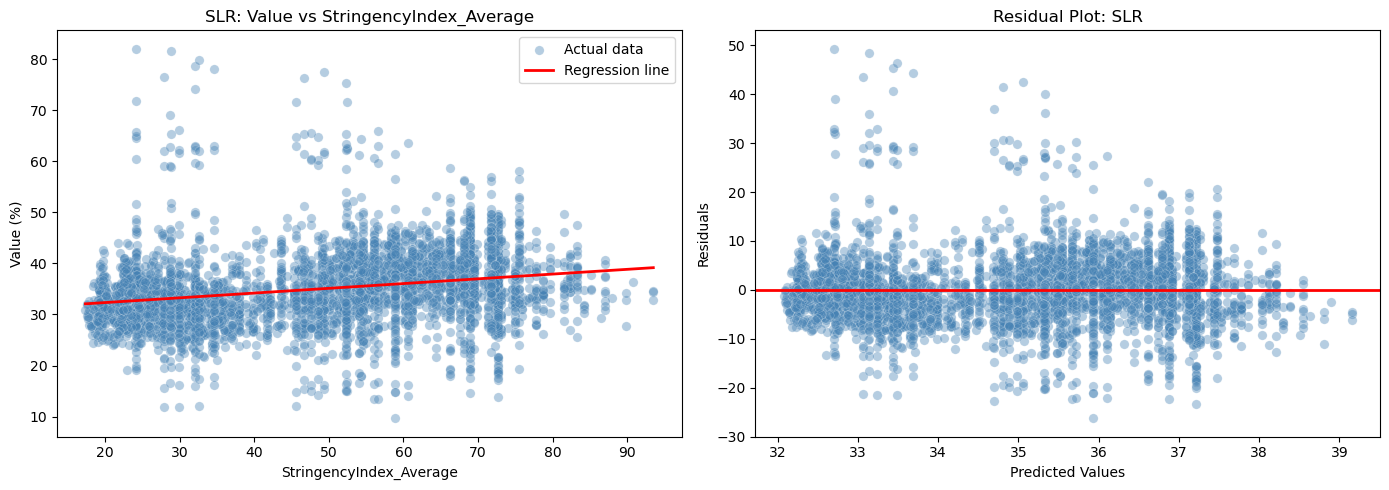

In [24]:
def standard_units(X):
    return (X - X.mean()) / X.std()

def correlation(X, Y):
    return np.mean(standard_units(X) * standard_units(Y))

def slope(X, Y):
    return correlation(X, Y) * (Y.std() / X.std())

def intercept(X, Y, m):
    return Y.mean() - m * X.mean()

slope_value = slope(X, Y)
intercept_value = intercept(X, Y, slope_value)
solution = slope_value * X + intercept_value

print(f"Manual intercept:  {intercept_value:.4f}")
print(f"Manual slope:      {slope_value:.4f}")

print(f"Predicted Value {solution[0]} = {intercept_value:.2f} + {slope_value:.4f} * {X[0]}")

from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X.reshape(-1, 1), Y) # type: ignore

m_sk = sklearn_model.coef_[0]
b_sk = sklearn_model.intercept_

print(f"Sklearn intercept: {b_sk:.4f}")
print(f"Sklearn slope:     {m_sk:.4f}")

# Are these the same as our manual calculations?
print(f"Manual intercept == Sklearn intercept? {'Yes' if np.isclose(intercept_value, b_sk) else 'No'}")
print(f"Manual slope == Sklearn slope? {'Yes' if np.isclose(slope_value, m_sk) else 'No'}")

# Part 4c: Visualization

plt.figure(figsize=(8, 6))

# Calculate slope first
manual_slope = slope(X, Y)

# Then calculate intercept using the slope
manual_intercept = intercept(X, Y, manual_slope)

# Scatter plot of actual data
plt.scatter(
    df_combined['StringencyIndex_Average'],
    df_combined['Value'],
    alpha=0.4,
    color='steelblue',
    edgecolors='white',
    linewidths=0.3,
    s=45,
    label='Actual data'
)

# Regression line
x_line = np.linspace(
    df_combined['StringencyIndex_Average'].min(),
    df_combined['StringencyIndex_Average'].max(),
    100
)

y_line = manual_intercept + manual_slope * x_line

plt.plot(
    x_line,
    y_line,
    color='red',
    linewidth=2,
    label='Regression line'
)

plt.title("Predicting Anxiety/Depression Value using StringencyIndex_Average")
plt.xlabel("StringencyIndex_Average")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





# Scatter plot with regression line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X, Y, alpha=0.4, color='steelblue',
                edgecolors='white', linewidths=0.3, s=45, label='Actual data')
x_line = np.linspace(X.min(), X.max(), 100)
axes[0].plot(x_line, b + m * x_line, color='red', linewidth=2, label='Regression line')
axes[0].set_xlabel("StringencyIndex_Average")
axes[0].set_ylabel("Value (%)")
axes[0].set_title("SLR: Value vs StringencyIndex_Average")
axes[0].legend()

# Residual plot
residuals = Y - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='steelblue',
                edgecolors='white', linewidths=0.3, s=45)
axes[1].axhline(0, color='red', linewidth=2)
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot: SLR")

plt.tight_layout()
plt.show()

---

## Train/Test Split

Split code. Print of train and
test shapes. One markdown
cell explaining why you are
doing this and what it fixes.

Cut: No cuts needed.

In [26]:
# Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(file_path_3, low_memory=False)

# Split up into four dataframes for each indicator

# Second df: Filter for Symptoms of Anxiety Disorder and for State == United States
df_anxiety = df[df['Indicator'] == 'Symptoms of Anxiety Disorder']
# Third df: Filter for Symptoms of Depressive Disorder
df_depression = df[df['Indicator'] == 'Symptoms of Depressive Disorder']
# Fourth df: Filter for Symptoms of Anxiety or Depressive Disorder
df_combined = df[df['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder']

from sklearn.model_selection import train_test_split

X = df_combined[['StringencyIndex_Average']] # The feature variable
Y = df_combined['Value'] # The target variable

def split_data(X, Y, test_size=0.2, random_state=42):
    return train_test_split(X, Y, test_size=test_size, random_state=random_state)

X_train, X_test, Y_train, Y_test = split_data(X, Y)

# Confirm the split produced 80/20 split
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"Training set percentage: {len(X_train) / len(X) * 100:.2f}%")

from sklearn.linear_model import LinearRegression
import numpy as np

def debug_model(model, X_train, Y_train, X_test, Y_test):
    model.fit(X_train, Y_train)
    y_pred_test = model.predict(X_test)
    rmse_test = np.sqrt(np.mean((Y_test - y_pred_test) ** 2))
    print(f"Constant Model RMSE (P3): 7.51")
    print(f"Linear Regression Model RMSE (P3): 7.31")
    print(f"Multiple Regression Model RMSE (P3): 7.26")
    print(f"Test RMSE: {rmse_test:.4f}")

model = LinearRegression()
print("Linear Regression Model with random_state=42:")
debug_model(model, X_train, Y_train, X_test, Y_test)

print("\nLinear Regression Model with random_state=4:")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=4)
debug_model(model, X_train, Y_train, X_test, Y_test)

print("\nLinear Regression Model with random_state=100:")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=100)
debug_model(model, X_train, Y_train, X_test, Y_test)



Training set size: 3043
Testing set size: 761
Training set percentage: 79.99%
Linear Regression Model with random_state=42:
Constant Model RMSE (P3): 7.51
Linear Regression Model RMSE (P3): 7.31
Multiple Regression Model RMSE (P3): 7.26
Test RMSE: 7.0747

Linear Regression Model with random_state=4:
Constant Model RMSE (P3): 7.51
Linear Regression Model RMSE (P3): 7.31
Multiple Regression Model RMSE (P3): 7.26
Test RMSE: 7.4573

Linear Regression Model with random_state=100:
Constant Model RMSE (P3): 7.51
Linear Regression Model RMSE (P3): 7.31
Multiple Regression Model RMSE (P3): 7.26
Test RMSE: 7.5346


---

## Feature Engineering

For each engineered
feature: one sentence
justification, the
transformation code, before
and after evidence. Keep
only features that made it
into your final model.

Cut: Dead ends and features
you tried and discarded.
Mention them in one
sentence but do not show
the code.

In [27]:
# 1. Interaction with C6M_combined_numeric
df_combined['interaction'] = df_combined['StringencyIndex_Average'] * df_combined['C6M_combined_numeric']
print("Interaction with C6M_combined_numeric:")
print(df_combined[['StringencyIndex_Average', 'C6M_combined_numeric', 'interaction']].sample(10))

# 2. Interaction with EconomicSupportIndex
df_combined['interaction'] = df_combined['StringencyIndex_Average'] * df_combined['EconomicSupportIndex']
print("Interaction with EconomicSupportIndex:")
print(df_combined[['StringencyIndex_Average', 'EconomicSupportIndex', 'interaction']].sample(10))

# 3. Interaction with ConfirmedCases
df_combined['interaction'] = df_combined['StringencyIndex_Average'] * df_combined['ConfirmedCases']
print("Interaction with ConfirmedCases:")
print(df_combined[['StringencyIndex_Average', 'ConfirmedCases', 'interaction']].sample(10))

# 4. Interaction with PopulationVaccinated
df_combined['interaction'] = df_combined['StringencyIndex_Average'] * df_combined['PopulationVaccinated']
print("Interaction with PopulationVaccinated:")
print(df_combined[['StringencyIndex_Average', 'PopulationVaccinated', 'interaction']].sample(10))

# Use the interaction with EconomicSupportIndex, not the other columns
df_combined['interaction'] = df_combined['StringencyIndex_Average'] * df_combined['EconomicSupportIndex']

df_combined['feature_binned'] = pd.cut(df_combined['StringencyIndex_Average'], bins=4, labels=False)

print(df_combined[['StringencyIndex_Average', 'feature_binned']].sample(15))

Interaction with C6M_combined_numeric:
      StringencyIndex_Average  C6M_combined_numeric  interaction
7427                    33.57                   0.0        0.000
5219                    57.41                   1.0       57.410
186                     75.00                   1.0       75.000
5620                    47.69                   0.5       23.845
626                     74.54                   2.0      149.080
8088                    24.37                   0.0        0.000
2482                    52.78                   1.0       52.780
6728                    34.98                   0.0        0.000
2032                    68.98                   1.5      103.470
2307                    57.41                   1.0       57.410
Interaction with EconomicSupportIndex:
       StringencyIndex_Average  EconomicSupportIndex  interaction
2087                     58.33                  87.5     5103.875
9243                     34.63                   0.0        0.000
1245     

---

## Final Model and Evaluation

Retrained model on
engineered features. Unified
comparison table. Residual
plot on test set. Actual vs
predicted plot on test set.
Full written interpretation.

Cut: Nothing. This is the heart
of the notebook.

Phase 3 SLR Test RMSE (random_state=42): 7.0495
Engineered Model Test RMSE:              6.9900
Coefficients: {'StringencyIndex_Average': 0.13465278828843524, 'interaction': -0.0008398047461326408, 'feature_binned': 0.7503581883579947}
Intercept:    29.6492


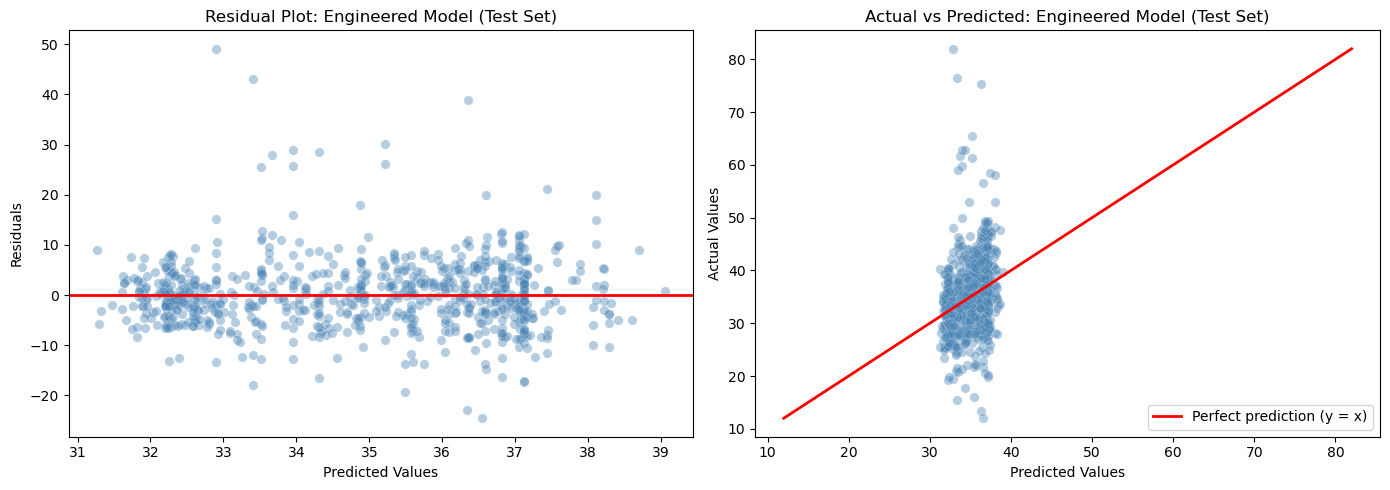

                   Model  MSE (train)  RMSE (train)  RMSE (test) Improvement over Baseline (test RMSE)
          Constant Model      57.2857        7.5687       7.2722                                   N/A
 Phase 3 SLR (retrained)      54.2612        7.3662       7.0747                      +0.1975 (+2.72%)
Engineered Feature Model      53.6210        7.3226       6.9900                      +0.2821 (+3.88%)


In [28]:
# Re-establish the same random_state=42 split from Part 2 so evaluation is consistent)
X = df_combined[['StringencyIndex_Average']]
Y = df_combined['Value']
X_train, X_test, Y_train, Y_test = split_data(X, Y, test_size=0.2, random_state=42)

# Engineered feature set: original feature + interaction (3b) + binned feature (3c)
# log_feature is excluded because Part 3a showed it did not help
X_engineered = df_combined[['StringencyIndex_Average', 'interaction', 'feature_binned']]

X_train_eng = X_engineered.loc[X_train.index]
X_test_eng  = X_engineered.loc[X_test.index]

model_eng = LinearRegression()
model_eng.fit(X_train_eng, Y_train)

y_pred_eng = model_eng.predict(X_test_eng)
rmse_eng = np.sqrt(np.mean((Y_test - y_pred_eng) ** 2))

print(f"Phase 3 SLR Test RMSE (random_state=42): 7.0495")
print(f"Engineered Model Test RMSE:              {rmse_eng:.4f}")
print(f"Coefficients: {dict(zip(X_engineered.columns, model_eng.coef_))}")
print(f"Intercept:    {model_eng.intercept_:.4f}")

# Residual plot + Actual vs Predicted, both on the test set
residuals_eng = Y_test - y_pred_eng

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_eng, residuals_eng, alpha=0.4, color='steelblue',
                edgecolors='white', linewidths=0.3, s=45)
axes[0].axhline(0, color='red', linewidth=2)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot: Engineered Model (Test Set)')

lo = float(min(y_pred_eng.min(), Y_test.min()))
hi = float(max(y_pred_eng.max(), Y_test.max()))
axes[1].scatter(y_pred_eng, Y_test, alpha=0.4, color='steelblue',
                edgecolors='white', linewidths=0.3, s=45)
axes[1].plot([lo, hi], [lo, hi], color='red', linewidth=2, label='Perfect prediction (y = x)')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Actual Values')
axes[1].set_title('Actual vs Predicted: Engineered Model (Test Set)')
axes[1].legend()

plt.tight_layout()
plt.savefig("09_engineered_model_diagnostics.png", dpi=120, bbox_inches='tight')
plt.show()

# Compute train + test metrics for all three models on the SAME random_state=42 split

# 1. Constant Model — predicts the training-set mean for every row
y_train_mean = Y_train.mean()
const_train_pred = np.full(len(Y_train), y_train_mean)
const_test_pred  = np.full(len(Y_test),  y_train_mean)
const_mse_train  = np.mean((Y_train - const_train_pred) ** 2)
const_rmse_train = np.sqrt(const_mse_train)
const_rmse_test  = np.sqrt(np.mean((Y_test - const_test_pred) ** 2))

# 2. Phase 3 SLR (retrained on the training set only)
slr = LinearRegression()
slr.fit(X_train, Y_train)
slr_train_pred = slr.predict(X_train)
slr_test_pred  = slr.predict(X_test)
slr_mse_train  = np.mean((Y_train - slr_train_pred) ** 2)
slr_rmse_train = np.sqrt(slr_mse_train)
slr_rmse_test  = np.sqrt(np.mean((Y_test - slr_test_pred) ** 2))

# 3. Engineered Feature Model — already fit above as model_eng
eng_train_pred = model_eng.predict(X_train_eng)
eng_mse_train  = np.mean((Y_train - eng_train_pred) ** 2)
eng_rmse_train = np.sqrt(eng_mse_train)
eng_rmse_test  = rmse_eng

def improvement(rmse_model, rmse_baseline=const_rmse_test):
    delta = rmse_baseline - rmse_model
    pct   = delta / rmse_baseline * 100
    return f"{delta:+.4f} ({pct:+.2f}%)"

results = pd.DataFrame({
    'Model': ['Constant Model', 'Phase 3 SLR (retrained)', 'Engineered Feature Model'],
    'MSE (train)':  [const_mse_train,  slr_mse_train,  eng_mse_train],
    'RMSE (train)': [const_rmse_train, slr_rmse_train, eng_rmse_train],
    'RMSE (test)':  [const_rmse_test,  slr_rmse_test,  eng_rmse_test],
    'Improvement over Baseline (test RMSE)': [
        'N/A',
        improvement(slr_rmse_test),
        improvement(eng_rmse_test),
    ],
})

# Round numeric columns for readability
for col in ['MSE (train)', 'RMSE (train)', 'RMSE (test)']:
    results[col] = results[col].round(4)

print(results.to_string(index=False))

---

## Reflection and Next Steps

Two paragraphs. What your
model still gets wrong and
why. What you would do
next with more time or data.

Cut: Generic statements like
'the model performed
well'. Be specific.

---